# 08 — Anomaly Concepts and Baseline Matching
## การสร้าง Anomaly อย่างถูกต้อง: Variable + Month + Pressure Level + Grid + Units ต้องตรงกัน

**กลุ่มผู้เรียน:** นิสิตปริญญาตรีชั้นปีที่ 3–4 ด้านสิ่งแวดล้อม ภูมิศาสตร์ และภูมิสารสนเทศ  
**Platform:** Google Colab + Google Drive  
**ข้อมูลหลัก:** ERA5 Jan/Jul monthly-mean archive, 1981–2020  
**ตัวอย่าง target:** January 2011 และ July 2011 ที่ 850 hPa  
**บทก่อนหน้า:** Notebook 07 — Climatology and Seasonal Circulation

Notebook นี้ตอบคำถามหลักว่า:

```text
anomaly คืออะไร?
        ↓
baseline คืออะไร?
        ↓
baseline ต้อง match อะไรบ้าง?
        ↓
January ต้องลบ January climatology เพราะอะไร?
        ↓
standardized anomaly คืออะไร?
        ↓
ทำไม October 2011 ยังทำ climatological anomaly
จาก Jan/Jul archive ไม่ได้?
```

> **Anomaly ที่ดีต้องเริ่มจาก baseline matching ไม่ใช่เริ่มจากคำสั่ง subtraction**

# Learning Objectives

เมื่อจบบทนี้ นิสิตควรสามารถ:

1. อธิบาย anomaly และ climatological baseline
2. แยก absolute anomaly กับ standardized anomaly
3. ตรวจ variable, calendar month, pressure level, grid, units และ temporal semantics
4. คำนวณ January 2011 anomaly เทียบ January 1981–2020 climatology
5. คำนวณ July 2011 anomaly เทียบ July 1981–2020 climatology
6. คำนวณ temperature, RH, geopotential-height และ wind-component anomalies
7. คำนวณ wind-vector anomaly จาก $u'$ และ $v'$
8. อธิบาย standardized anomaly หรือ z-score
9. สร้าง anomaly maps ที่ใช้ zero-centered color scale
10. สร้าง regional anomaly time series
11. สาธิตว่า October 2011 baseline matching ล้มเหลวเพราะไม่มี October climatology
12. อธิบายว่า anomaly ไม่เท่ากับ trend, extreme หรือ statistical significance
13. export anomaly products, compatibility report และ metadata

# 1. Anomaly

$$
X'
=
X
-
\overline{X}_{clim}
$$

โดย:

- $X$ = target value
- $\overline{X}_{clim}$ = matching climatological mean
- $X'$ = anomaly

# 2. Calendar Matching

January 2011:

$$
X'_{Jan2011}
=
X_{Jan2011}
-
\overline{X}_{Jan,1981-2020}
$$

July 2011:

$$
X'_{Jul2011}
=
X_{Jul2011}
-
\overline{X}_{Jul,1981-2020}
$$

แต่ไม่ควรทำ:

$$
X_{Oct2011}
-
\overline{X}_{Jan}
$$

# 3. Baseline Matching Checklist

ก่อน subtraction ต้องตรวจ:

```text
1. Variable
2. Calendar month / season
3. Pressure level
4. Horizontal grid
5. Coordinate ordering
6. Units
7. Temporal meaning
8. Baseline period
```

# 4. Absolute และ Standardized Anomaly

Absolute anomaly:

$$
X'
=
X-\overline{X}
$$

Standardized anomaly:

$$
Z
=
\frac{X-\mu}{\sigma}
$$

> **standardized anomaly ≠ statistical significance โดยอัตโนมัติ**

# 5. Temperature Anomaly ใน K และ °C

เพราะ:

$$
T_{^\circ C}=T_K-273.15
$$

จึงได้:

$$
T'_{^\circ C}=T'_K
$$

สำหรับ temperature difference ค่าตัวเลขใน K และ °C เท่ากัน

# 6. Wind Anomaly

$$
u'=u-\overline{u}
$$

$$
v'=v-\overline{v}
$$

และ:

$$
|\vec{V}'|
=
\sqrt{u'^2+v'^2}
$$

vector anomaly magnitude ไม่เหมือนกับ wind-speed anomaly $V-\overline{V}$

# 7. Relative Humidity Anomaly

$$
RH'=RH-\overline{RH}
$$

ถ้า RH ใช้หน่วย percent ผลต่างควรเรียกว่า **percentage points**

# 8. Anomaly ≠ Trend ≠ Extreme

```text
anomaly ≠ trend
large anomaly ≠ extreme automatically
standardized anomaly ≠ statistical significance automatically
```

# 9. October 2011 Limitation

Teaching archive มีเฉพาะ January และ July

ดังนั้นไม่มี October climatology และ EVENT dataset เป็น 00-UTC synoptic snapshots ไม่ใช่ October monthly mean

> **Notebook 08 จะไม่สร้าง October anomaly แบบฝืน baseline**

# 10. ติดตั้งไลบรารี

In [3]:
# CELL 1 — Install/check libraries

import sys
import subprocess

PACKAGES = [
    "xarray>=2025.1",
    "netCDF4>=1.7",
    "h5netcdf>=1.4",
    "dask[array]>=2025.1",
    "numpy>=1.26",
    "pandas>=2.2",
    "matplotlib>=3.8",
    "cartopy>=0.23",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade-strategy",
        "only-if-needed",
        *PACKAGES,
    ]
)

print("Libraries ready.")

Libraries ready.


# 11. Mount Google Drive

In [4]:
# CELL 2 — Mount Google Drive

from pathlib import Path
from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False,
)

DRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)

print("Google Drive mounted:", DRIVE_ROOT)

Mounted at /content/drive
Google Drive mounted: /content/drive/MyDrive


# 12. Import libraries

In [5]:
# CELL 3 — Imports

from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from IPython.display import display

G0 = 9.80665

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Xarray:", xr.__version__)

Python: 3.13.15
NumPy: 2.1.3
pandas: 2.2.3
Xarray: 2025.12.0


# 13. Course paths — ใช้ชื่อไฟล์เดียวกับ Notebook 00

In [6]:
# CELL 4 — Course paths

COURSE_ROOT = (
    DRIVE_ROOT
    / "Teaching_ERA5_Reanalysis_GIS"
)

SOURCE_GITHUB_DIR = (
    COURSE_ROOT
    / "00_source_github"
)

METADATA_DIR = (
    COURSE_ROOT
    / "02_metadata"
)

OUTPUT_DIR = (
    COURSE_ROOT
    / "03_output"
)

FIGURE_DIR = (
    COURSE_ROOT
    / "04_figures"
    / "08"
)

for folder in [
    METADATA_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

MONTHLY_BASELINE_CANDIDATES = [
    (
        SOURCE_GITHUB_DIR
        / "era5_850hPa_JanJul_monthlymeans_1981_2020_Asia_0.5deg.nc"
    ),
    (
        SOURCE_GITHUB_DIR
        / "era5_850hPa_JanJul_1981_2020_Asia_0.5deg.nc"
    ),
]

MONTHLY_BASELINE_FILE = next(
    (
        path
        for path in MONTHLY_BASELINE_CANDIDATES
        if path.exists()
    ),
    None,
)

EVENT_FILE = (
    SOURCE_GITHUB_DIR
    / "era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc"
)

if MONTHLY_BASELINE_FILE is None:
    available_nc_files = sorted(
        path.name
        for path in SOURCE_GITHUB_DIR.glob("*.nc")
    )
    raise FileNotFoundError(
        "Jan/Jul monthly-mean archive was not found.\n\n"
        f"Expected folder:\n{SOURCE_GITHUB_DIR}\n\n"
        "Expected filename from Notebook 00:\n"
        "era5_850hPa_JanJul_monthlymeans_1981_2020_Asia_0.5deg.nc\n\n"
        f"NetCDF files currently found:\n{available_nc_files}"
    )

if not EVENT_FILE.exists():
    raise FileNotFoundError(
        f"EVENT dataset not found: {EVENT_FILE}"
    )

print("Monthly baseline archive:", MONTHLY_BASELINE_FILE)
print("EVENT file:", EVENT_FILE)

Monthly baseline archive: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/00_source_github/era5_850hPa_JanJul_monthlymeans_1981_2020_Asia_0.5deg.nc
EVENT file: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/00_source_github/era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc


# 14. เปิด Monthly Archive และ EVENT Dataset

In [7]:
# CELL 5 — Open datasets

monthly_ds = xr.open_dataset(
    MONTHLY_BASELINE_FILE,
    decode_times=True,
)

event_ds = xr.open_dataset(
    EVENT_FILE,
    decode_times=True,
)

print("MONTHLY ARCHIVE")
print(monthly_ds)

print()
print("EVENT DATASET")
print(event_ds)

MONTHLY ARCHIVE
<xarray.Dataset> Size: 34MB
Dimensions:                    (time: 80, latitude: 110, longitude: 160)
Coordinates:
  * time                       (time) datetime64[ns] 640B 1981-01-01 ... 2020...
  * latitude                   (latitude) float32 440B 44.88 44.38 ... -9.625
  * longitude                  (longitude) float32 640B 60.12 60.62 ... 139.6
    source_pressure_level_hPa  float64 8B ...
Data variables:
    z                          (time, latitude, longitude) float32 6MB ...
    r                          (time, latitude, longitude) float32 6MB ...
    t                          (time, latitude, longitude) float32 6MB ...
    u                          (time, latitude, longitude) float32 6MB ...
    v                          (time, latitude, longitude) float32 6MB ...
    vo                         (time, latitude, longitude) float32 6MB ...
Attributes: (12/20)
    Conventions:                           CF-1.6
    history:                               2022-04-

# 15. Dataset Audit

In [8]:
# CELL 6 — Dataset audit

monthly_time = pd.DatetimeIndex(
    pd.to_datetime(
        monthly_ds["time"].values
    )
)

event_time = pd.DatetimeIndex(
    pd.to_datetime(
        event_ds["time"].values
    )
)

monthly_months = sorted(
    np.unique(
        monthly_time.month
    ).tolist()
)

monthly_years = sorted(
    np.unique(
        monthly_time.year
    ).tolist()
)

DATASET_AUDIT = pd.DataFrame(
    [
        {
            "dataset": "MONTHLY_BASELINE",
            "temporal_semantics": "monthly means",
            "time_start": str(monthly_time.min()),
            "time_end": str(monthly_time.max()),
            "months_present": str(monthly_months),
            "n_time": int(monthly_ds.sizes["time"]),
            "has_level_dimension": "level" in monthly_ds.dims,
        },
        {
            "dataset": "EVENT",
            "temporal_semantics": "daily 00-UTC synoptic snapshots",
            "time_start": str(event_time.min()),
            "time_end": str(event_time.max()),
            "months_present": str(
                sorted(
                    np.unique(
                        event_time.month
                    ).tolist()
                )
            ),
            "n_time": int(event_ds.sizes["time"]),
            "has_level_dimension": "level" in event_ds.dims,
        },
    ]
)

display(DATASET_AUDIT)

,dataset,temporal_semantics,time_start,time_end,months_present,n_time,has_level_dimension
0,MONTHLY_BASELINE,monthly means,1981-01-01 00:00:00,2020-07-01 00:00:00,"[1, 7]",80,False
1,EVENT,daily 00-UTC synoptic snapshots,2011-10-02 00:00:00,2011-10-05 00:00:00,[10],4,True


# 16. Helper Functions และ Analysis Domains

In [9]:
# CELL 7 — Helpers and domains

SE_ASIA_DOMAIN = {
    "lon_min": 80.0,
    "lon_max": 130.0,
    "lat_min": 0.0,
    "lat_max": 35.0,
}

THAILAND_BOX = {
    "lon_min": 97.0,
    "lon_max": 106.0,
    "lat_min": 5.0,
    "lat_max": 21.0,
}


def coordinate_slice(
    coordinate,
    lower,
    upper,
):
    values = np.asarray(
        coordinate.values
    )

    if values[-1] > values[0]:
        return slice(
            lower,
            upper,
        )

    return slice(
        upper,
        lower,
    )


def subset_domain(
    data_array,
    domain,
):
    return data_array.sel(
        latitude=coordinate_slice(
            data_array["latitude"],
            domain["lat_min"],
            domain["lat_max"],
        ),
        longitude=coordinate_slice(
            data_array["longitude"],
            domain["lon_min"],
            domain["lon_max"],
        ),
    )


def decorate_map(
    ax,
    domain,
):
    ax.coastlines(
        resolution="110m",
        linewidth=0.7,
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.5,
    )

    ax.set_extent(
        [
            domain["lon_min"],
            domain["lon_max"],
            domain["lat_min"],
            domain["lat_max"],
        ],
        crs=ccrs.PlateCarree(),
    )

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.35,
        alpha=0.45,
        linestyle="--",
    )

    gl.top_labels = False
    gl.right_labels = False


def weighted_regional_mean(
    data_array,
    domain,
):
    subset = subset_domain(
        data_array,
        domain,
    )

    weights = np.cos(
        np.deg2rad(
            subset["latitude"]
        )
    )

    return (
        subset
        .weighted(
            weights
        )
        .mean(
            dim=(
                "latitude",
                "longitude",
            )
        )
    )

# 17. Baseline Compatibility Report

In [10]:
# CELL 8 — Compatibility report

compatibility_rows = [
    {
        "case": (
            "January 2011 monthly mean "
            "vs January 1981–2020 climatology"
        ),
        "variable": "PASS",
        "calendar_month": "PASS",
        "pressure_level": "PASS",
        "grid": "PASS",
        "units": "PASS",
        "temporal_semantics": "PASS",
        "overall": "PASS",
    },
    {
        "case": (
            "July 2011 monthly mean "
            "vs July 1981–2020 climatology"
        ),
        "variable": "PASS",
        "calendar_month": "PASS",
        "pressure_level": "PASS",
        "grid": "PASS",
        "units": "PASS",
        "temporal_semantics": "PASS",
        "overall": "PASS",
    },
    {
        "case": (
            "2 Oct 2011 00 UTC EVENT snapshot "
            "vs Jan/Jul monthly climatology"
        ),
        "variable": "PASS",
        "calendar_month": "FAIL",
        "pressure_level": "PASS",
        "grid": "NOT USED",
        "units": "PASS",
        "temporal_semantics": "FAIL",
        "overall": "FAIL",
    },
]

BASELINE_COMPATIBILITY = pd.DataFrame(
    compatibility_rows
)

display(
    BASELINE_COMPATIBILITY
)

,case,variable,calendar_month,pressure_level,grid,units,temporal_semantics,overall
0,January 2011 monthly mean vs January 1981–2020...,PASS,PASS,PASS,PASS,PASS,PASS,PASS
1,July 2011 monthly mean vs July 1981–2020 clima...,PASS,PASS,PASS,PASS,PASS,PASS,PASS
2,2 Oct 2011 00 UTC EVENT snapshot vs Jan/Jul mo...,PASS,FAIL,PASS,NOT USED,PASS,FAIL,FAIL


# 18. October Case ต้อง FAIL

เหตุผลสำคัญ:

```text
ไม่มี October climatology
+
EVENT เป็น 00-UTC snapshot
ไม่ใช่ October monthly mean
```

ดังนั้นจะไม่สร้าง October anomaly จาก baseline ที่ไม่ match

# 19. สร้าง Climatology และ Standard Deviation

In [11]:
# CELL 9 — Monthly climatology and variability

jan_archive = monthly_ds.sel(
    time=(
        monthly_ds["time"].dt.month
        == 1
    )
)

jul_archive = monthly_ds.sel(
    time=(
        monthly_ds["time"].dt.month
        == 7
    )
)

JAN_MEAN = jan_archive.mean(
    dim="time",
    keep_attrs=True,
)

JUL_MEAN = jul_archive.mean(
    dim="time",
    keep_attrs=True,
)

JAN_STD = jan_archive.std(
    dim="time",
    ddof=1,
    keep_attrs=True,
)

JUL_STD = jul_archive.std(
    dim="time",
    ddof=1,
    keep_attrs=True,
)

print("January baseline years:", jan_archive.sizes["time"])
print("July baseline years:", jul_archive.sizes["time"])

January baseline years: 40
July baseline years: 40


# 20. เลือก Target: January 2011 และ July 2011

In [12]:
# CELL 10 — Target monthly means

JAN_2011 = monthly_ds.sel(
    time="2011-01-01"
)

JUL_2011 = monthly_ds.sel(
    time="2011-07-01"
)

print(
    "January target:",
    pd.Timestamp(
        JAN_2011["time"].values
    ),
)

print(
    "July target:",
    pd.Timestamp(
        JUL_2011["time"].values
    ),
)

January target: 2011-01-01 00:00:00
July target: 2011-07-01 00:00:00


# 21. คำนวณ Absolute และ Standardized Anomalies

In [13]:
# CELL 11 — Anomaly fields

JAN_ANOM = (
    JAN_2011
    - JAN_MEAN
)

JUL_ANOM = (
    JUL_2011
    - JUL_MEAN
)

JAN_T_ANOM = JAN_ANOM["t"]
JUL_T_ANOM = JUL_ANOM["t"]

JAN_RH_ANOM = JAN_ANOM["r"]
JUL_RH_ANOM = JUL_ANOM["r"]

JAN_Z_ANOM_M = (
    JAN_ANOM["z"]
    / G0
)

JUL_Z_ANOM_M = (
    JUL_ANOM["z"]
    / G0
)

JAN_U_ANOM = JAN_ANOM["u"]
JAN_V_ANOM = JAN_ANOM["v"]

JUL_U_ANOM = JUL_ANOM["u"]
JUL_V_ANOM = JUL_ANOM["v"]

JAN_T_Z = (
    JAN_ANOM["t"]
    / JAN_STD["t"]
).where(
    JAN_STD["t"]
    > 1.0e-6
)

JUL_T_Z = (
    JUL_ANOM["t"]
    / JUL_STD["t"]
).where(
    JUL_STD["t"]
    > 1.0e-6
)

print("Anomaly fields ready.")

Anomaly fields ready.


# 22. Figure 08-1 — January 2011 Temperature and Wind-Vector Anomaly

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


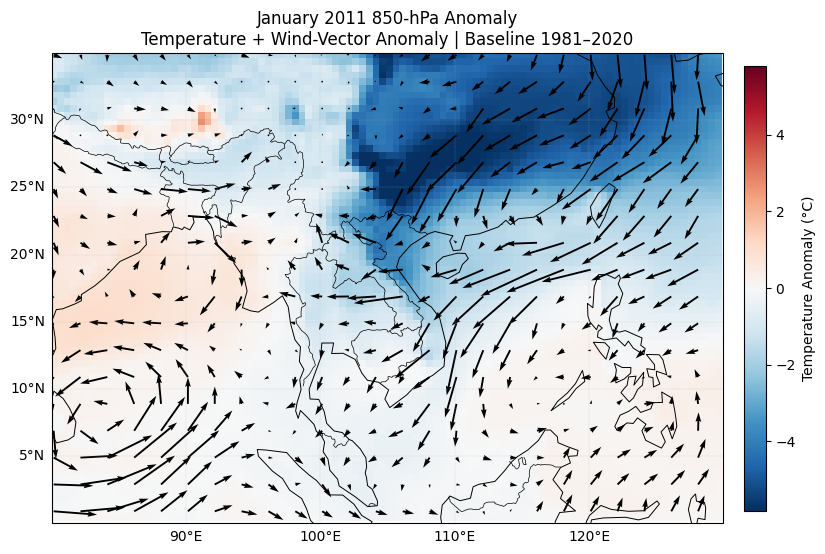

In [14]:
# CELL 12 — January anomaly map

temp = subset_domain(
    JAN_T_ANOM,
    SE_ASIA_DOMAIN,
)

u_anom = subset_domain(
    JAN_U_ANOM,
    SE_ASIA_DOMAIN,
)

v_anom = subset_domain(
    JAN_V_ANOM,
    SE_ASIA_DOMAIN,
)

absmax = float(
    np.nanpercentile(
        np.abs(
            temp.values
        ),
        99,
    )
)

absmax = max(
    absmax,
    0.5,
)

fig = plt.figure(
    figsize=(10.5, 6.8)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    temp["longitude"],
    temp["latitude"],
    temp,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="RdBu_r",
    norm=TwoSlopeNorm(
        vmin=-absmax,
        vcenter=0.0,
        vmax=absmax,
    ),
)

skip = 4

ax.quiver(
    u_anom["longitude"].values[::skip],
    u_anom["latitude"].values[::skip],
    u_anom.values[::skip, ::skip],
    v_anom.values[::skip, ::skip],
    transform=ccrs.PlateCarree(),
)

decorate_map(
    ax,
    SE_ASIA_DOMAIN,
)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "Temperature Anomaly (°C)"
)

ax.set_title(
    "January 2011 850-hPa Anomaly\n"
    "Temperature + Wind-Vector Anomaly | Baseline 1981–2020"
)

FIG_08_01 = (
    FIGURE_DIR
    / "08_01_january2011_temperature_wind_anomaly.png"
)

plt.savefig(
    FIG_08_01,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 23. Figure 08-2 — July 2011 Temperature and Wind-Vector Anomaly

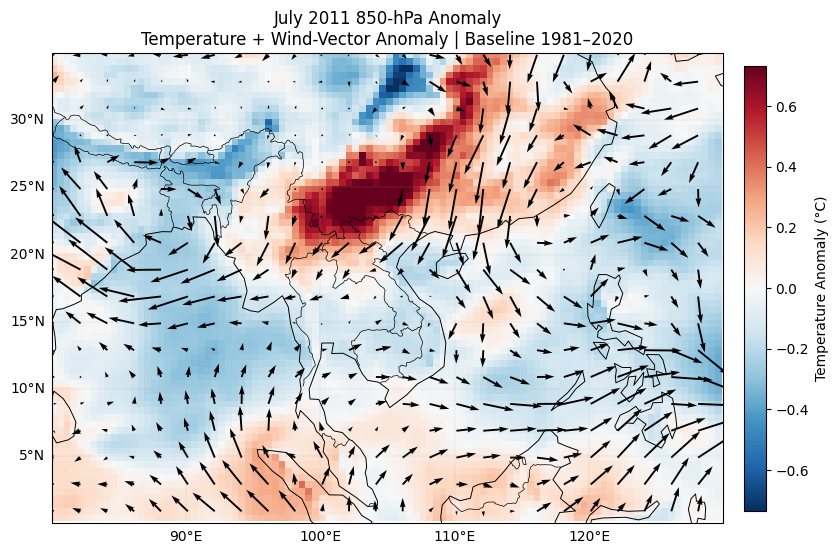

In [15]:
# CELL 13 — July anomaly map

temp = subset_domain(
    JUL_T_ANOM,
    SE_ASIA_DOMAIN,
)

u_anom = subset_domain(
    JUL_U_ANOM,
    SE_ASIA_DOMAIN,
)

v_anom = subset_domain(
    JUL_V_ANOM,
    SE_ASIA_DOMAIN,
)

absmax = float(
    np.nanpercentile(
        np.abs(
            temp.values
        ),
        99,
    )
)

absmax = max(
    absmax,
    0.5,
)

fig = plt.figure(
    figsize=(10.5, 6.8)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    temp["longitude"],
    temp["latitude"],
    temp,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="RdBu_r",
    norm=TwoSlopeNorm(
        vmin=-absmax,
        vcenter=0.0,
        vmax=absmax,
    ),
)

skip = 4

ax.quiver(
    u_anom["longitude"].values[::skip],
    u_anom["latitude"].values[::skip],
    u_anom.values[::skip, ::skip],
    v_anom.values[::skip, ::skip],
    transform=ccrs.PlateCarree(),
)

decorate_map(
    ax,
    SE_ASIA_DOMAIN,
)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "Temperature Anomaly (°C)"
)

ax.set_title(
    "July 2011 850-hPa Anomaly\n"
    "Temperature + Wind-Vector Anomaly | Baseline 1981–2020"
)

FIG_08_02 = (
    FIGURE_DIR
    / "08_02_july2011_temperature_wind_anomaly.png"
)

plt.savefig(
    FIG_08_02,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 24. Figure 08-3 — January and July 2011 RH Anomalies

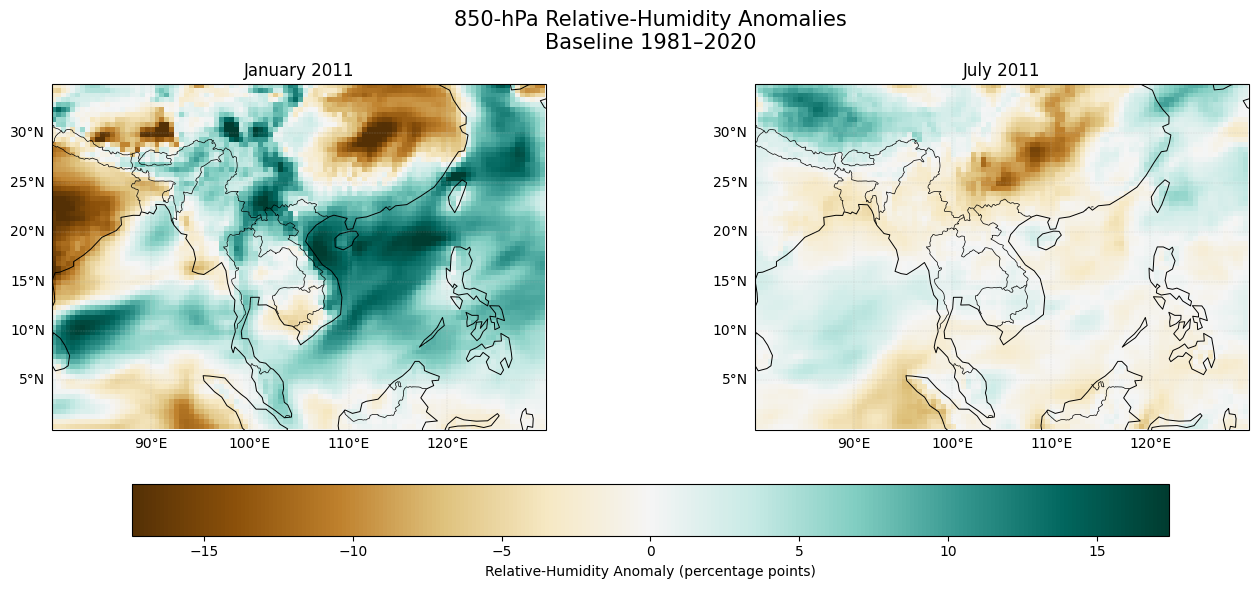

In [16]:
# CELL 14 — RH anomaly comparison

jan_rh = subset_domain(
    JAN_RH_ANOM,
    SE_ASIA_DOMAIN,
)

jul_rh = subset_domain(
    JUL_RH_ANOM,
    SE_ASIA_DOMAIN,
)

rh_abs = float(
    max(
        np.nanpercentile(
            np.abs(
                jan_rh.values
            ),
            99,
        ),
        np.nanpercentile(
            np.abs(
                jul_rh.values
            ),
            99,
        ),
    )
)

rh_abs = max(
    rh_abs,
    2.0,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.8),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    constrained_layout=True,
)

for ax, field, title in [
    (axes[0], jan_rh, "January 2011"),
    (axes[1], jul_rh, "July 2011"),
]:
    mesh = ax.pcolormesh(
        field["longitude"],
        field["latitude"],
        field,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="BrBG",
        norm=TwoSlopeNorm(
            vmin=-rh_abs,
            vcenter=0.0,
            vmax=rh_abs,
        ),
    )

    decorate_map(
        ax,
        SE_ASIA_DOMAIN,
    )

    ax.set_title(
        title
    )

cbar = fig.colorbar(
    mesh,
    ax=axes.tolist(),
    orientation="horizontal",
    pad=0.08,
    shrink=0.82,
)

cbar.set_label(
    "Relative-Humidity Anomaly (percentage points)"
)

fig.suptitle(
    "850-hPa Relative-Humidity Anomalies\n"
    "Baseline 1981–2020",
    fontsize=15,
)

FIG_08_03 = (
    FIGURE_DIR
    / "08_03_january_july2011_RH_anomalies.png"
)

plt.savefig(
    FIG_08_03,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 25. Figure 08-4 — Geopotential-Height Anomalies

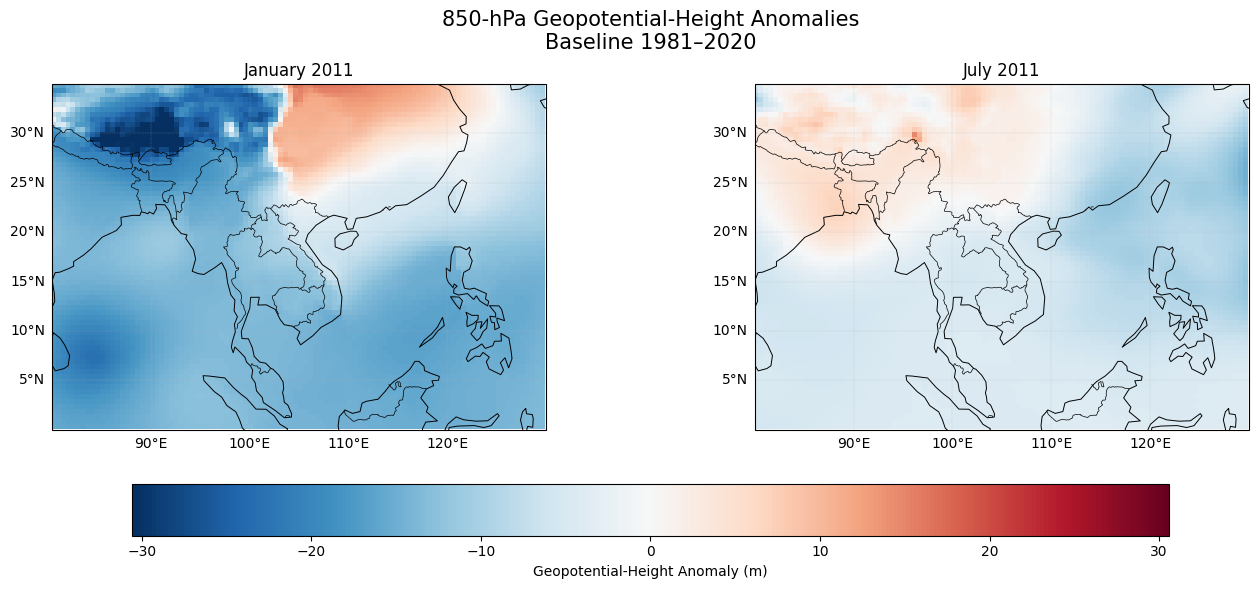

In [17]:
# CELL 15 — Geopotential-height anomaly comparison

jan_z = subset_domain(
    JAN_Z_ANOM_M,
    SE_ASIA_DOMAIN,
)

jul_z = subset_domain(
    JUL_Z_ANOM_M,
    SE_ASIA_DOMAIN,
)

z_abs = float(
    max(
        np.nanpercentile(
            np.abs(
                jan_z.values
            ),
            99,
        ),
        np.nanpercentile(
            np.abs(
                jul_z.values
            ),
            99,
        ),
    )
)

z_abs = max(
    z_abs,
    2.0,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.8),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    constrained_layout=True,
)

for ax, field, title in [
    (axes[0], jan_z, "January 2011"),
    (axes[1], jul_z, "July 2011"),
]:
    mesh = ax.pcolormesh(
        field["longitude"],
        field["latitude"],
        field,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="RdBu_r",
        norm=TwoSlopeNorm(
            vmin=-z_abs,
            vcenter=0.0,
            vmax=z_abs,
        ),
    )

    decorate_map(
        ax,
        SE_ASIA_DOMAIN,
    )

    ax.set_title(
        title
    )

cbar = fig.colorbar(
    mesh,
    ax=axes.tolist(),
    orientation="horizontal",
    pad=0.08,
    shrink=0.82,
)

cbar.set_label(
    "Geopotential-Height Anomaly (m)"
)

fig.suptitle(
    "850-hPa Geopotential-Height Anomalies\n"
    "Baseline 1981–2020",
    fontsize=15,
)

FIG_08_04 = (
    FIGURE_DIR
    / "08_04_january_july2011_geopotential_height_anomalies.png"
)

plt.savefig(
    FIG_08_04,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 26. Figure 08-5 — Standardized Temperature Anomalies

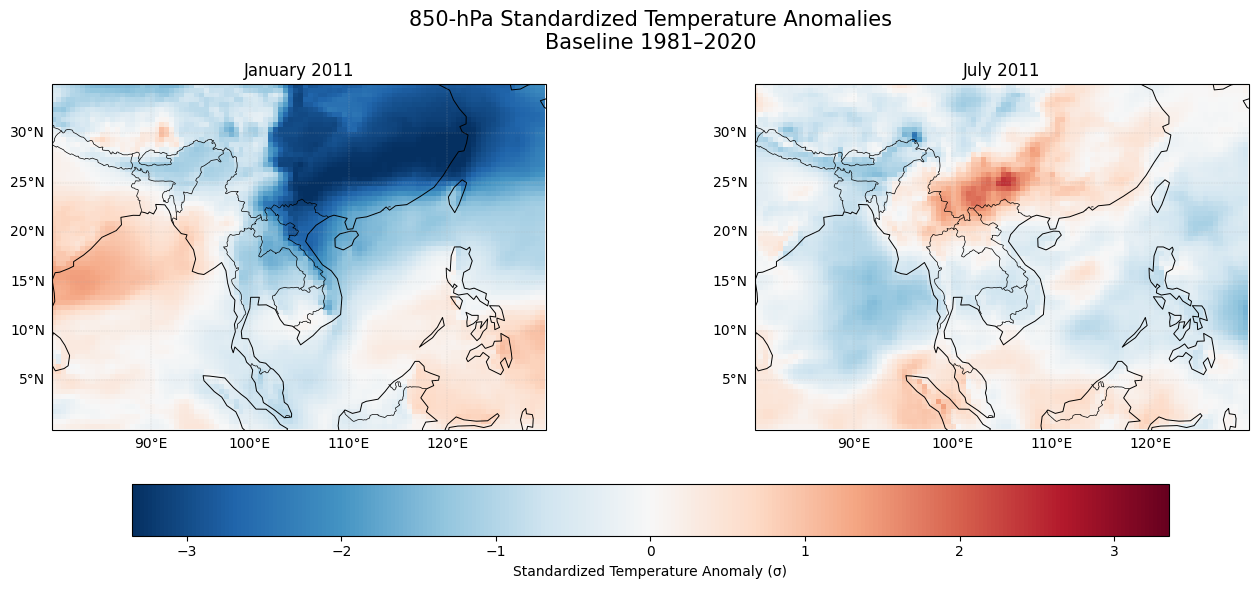

In [18]:
# CELL 16 — Standardized temperature anomaly comparison

jan_zscore = subset_domain(
    JAN_T_Z,
    SE_ASIA_DOMAIN,
)

jul_zscore = subset_domain(
    JUL_T_Z,
    SE_ASIA_DOMAIN,
)

zscore_abs = float(
    max(
        np.nanpercentile(
            np.abs(
                jan_zscore.values
            ),
            99,
        ),
        np.nanpercentile(
            np.abs(
                jul_zscore.values
            ),
            99,
        ),
    )
)

zscore_abs = max(
    zscore_abs,
    1.0,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.8),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    constrained_layout=True,
)

for ax, field, title in [
    (axes[0], jan_zscore, "January 2011"),
    (axes[1], jul_zscore, "July 2011"),
]:
    mesh = ax.pcolormesh(
        field["longitude"],
        field["latitude"],
        field,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="RdBu_r",
        norm=TwoSlopeNorm(
            vmin=-zscore_abs,
            vcenter=0.0,
            vmax=zscore_abs,
        ),
    )

    decorate_map(
        ax,
        SE_ASIA_DOMAIN,
    )

    ax.set_title(
        title
    )

cbar = fig.colorbar(
    mesh,
    ax=axes.tolist(),
    orientation="horizontal",
    pad=0.08,
    shrink=0.82,
)

cbar.set_label(
    "Standardized Temperature Anomaly (σ)"
)

fig.suptitle(
    "850-hPa Standardized Temperature Anomalies\n"
    "Baseline 1981–2020",
    fontsize=15,
)

FIG_08_05 = (
    FIGURE_DIR
    / "08_05_standardized_temperature_anomalies.png"
)

plt.savefig(
    FIG_08_05,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 27. Thailand-Box Anomaly Time Series

In [19]:
# CELL 17 — Regional monthly anomaly series

temperature_C = (
    monthly_ds["t"]
    - 273.15
)

temperature_clim = (
    temperature_C
    .groupby(
        "time.month"
    )
    .mean(
        dim="time"
    )
)

temperature_anomaly = (
    temperature_C.groupby(
        "time.month"
    )
    - temperature_clim
)

regional_t_anom = weighted_regional_mean(
    temperature_anomaly,
    THAILAND_BOX,
)

REGIONAL_ANOMALY_SERIES = pd.DataFrame(
    {
        "time": pd.to_datetime(
            regional_t_anom["time"].values
        ),
        "temperature_anomaly_C": (
            regional_t_anom.values
        ),
    }
)

REGIONAL_ANOMALY_SERIES[
    "year"
] = REGIONAL_ANOMALY_SERIES[
    "time"
].dt.year

REGIONAL_ANOMALY_SERIES[
    "month"
] = REGIONAL_ANOMALY_SERIES[
    "time"
].dt.month

REGIONAL_ANOMALY_SERIES[
    "month_name"
] = REGIONAL_ANOMALY_SERIES[
    "month"
].map(
    {
        1: "January",
        7: "July",
    }
)

display(
    REGIONAL_ANOMALY_SERIES.head()
)

,time,temperature_anomaly_C,year,month,month_name
0,1981-01-01,-1.228796,1981,1,January
1,1981-07-01,0.029288,1981,7,July
2,1982-01-01,-0.989873,1982,1,January
3,1982-07-01,-0.173443,1982,7,July
4,1983-01-01,-0.658777,1983,1,January


# 28. Figure 08-6 — Thailand-Box January/July Temperature Anomalies

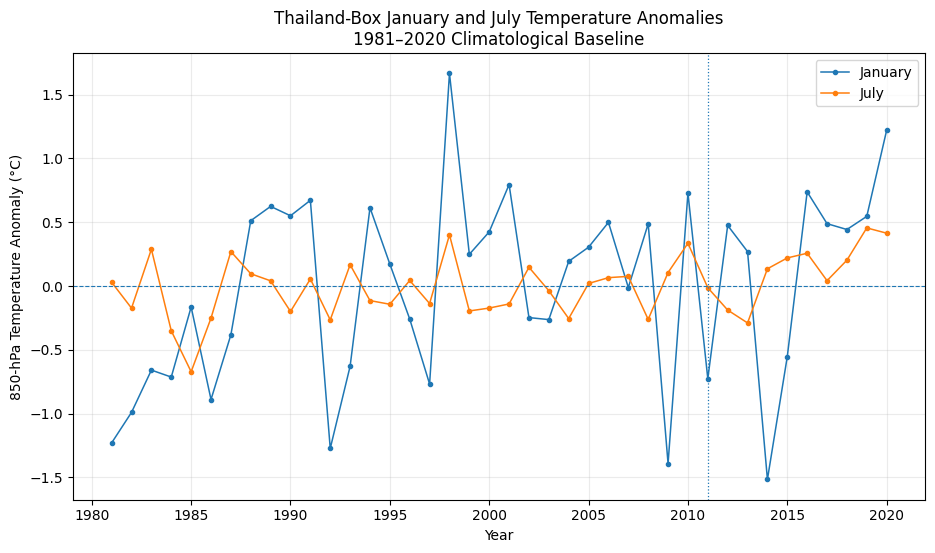

In [20]:
# CELL 18 — Regional anomaly time series figure

fig, ax = plt.subplots(
    figsize=(11, 5.8)
)

for month_name, group in (
    REGIONAL_ANOMALY_SERIES.groupby(
        "month_name"
    )
):
    group = group.sort_values(
        "year"
    )

    ax.plot(
        group["year"],
        group["temperature_anomaly_C"],
        marker="o",
        markersize=3,
        linewidth=1.1,
        label=month_name,
    )

ax.axhline(
    0.0,
    linewidth=0.8,
    linestyle="--",
)

ax.axvline(
    2011,
    linewidth=0.9,
    linestyle=":",
)

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "850-hPa Temperature Anomaly (°C)"
)

ax.set_title(
    "Thailand-Box January and July Temperature Anomalies\n"
    "1981–2020 Climatological Baseline"
)

ax.grid(
    True,
    alpha=0.25,
)

ax.legend()

FIG_08_06 = (
    FIGURE_DIR
    / "08_06_thailand_box_temperature_anomaly_series.png"
)

plt.savefig(
    FIG_08_06,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# 29. การอ่าน Anomaly Map

ควรอ่านตามลำดับ:

```text
Observation
→ anomaly sign และ magnitude

Context
→ absolute หรือ standardized anomaly?

Physical interpretation
→ atmospheric state differs from climatology อย่างไร?

Limitation
→ anomaly ไม่ได้บอก causal mechanism โดยตัวมันเอง
```

ตัวอย่าง:

```text
Observation:
Temperature anomaly is positive.

Interpretation:
The target month is warmer at 850 hPa than its matching climatological mean.

Limitation:
This alone does not establish a long-term warming trend.
```

# 30. 2011 Regional Anomaly Summary

In [21]:
# CELL 19 — 2011 regional anomaly summary

summary_rows = []

for month_name, target_anom in [
    (
        "January",
        JAN_ANOM,
    ),
    (
        "July",
        JUL_ANOM,
    ),
]:
    summary_rows.append(
        {
            "month": month_name,
            "temperature_anomaly_C": float(
                weighted_regional_mean(
                    target_anom["t"],
                    THAILAND_BOX,
                )
            ),
            "RH_anomaly_percentage_points": float(
                weighted_regional_mean(
                    target_anom["r"],
                    THAILAND_BOX,
                )
            ),
            "u_anomaly_ms": float(
                weighted_regional_mean(
                    target_anom["u"],
                    THAILAND_BOX,
                )
            ),
            "v_anomaly_ms": float(
                weighted_regional_mean(
                    target_anom["v"],
                    THAILAND_BOX,
                )
            ),
            "geopotential_height_anomaly_m": float(
                weighted_regional_mean(
                    target_anom["z"] / G0,
                    THAILAND_BOX,
                )
            ),
        }
    )

ANOMALY_2011_SUMMARY = pd.DataFrame(
    summary_rows
)

display(
    ANOMALY_2011_SUMMARY
)

,month,temperature_anomaly_C,RH_anomaly_percentage_points,u_anomaly_ms,v_anomaly_ms,geopotential_height_anomaly_m
0,January,-0.726038,2.942224,-0.810784,-0.228326,-12.740697
1,July,-0.013503,-0.395711,0.076451,0.053771,-4.445634


# 31. Export Anomaly Products

In [22]:
# CELL 20 — Export anomaly products
#
# IMPORTANT:
# JAN_* and JUL_* anomaly DataArrays carry different scalar "time"
# coordinates (2011-01-01 vs 2011-07-01).  If they are inserted
# directly into one xr.Dataset, Xarray correctly raises MergeError.
#
# We therefore remove only the scalar target-time coordinate before
# merging.  The target month/year remain explicit in each variable
# name and in the global metadata below.
#
# Do NOT solve this with compat="override" because that would silently
# discard a real coordinate conflict.

ANOMALY_NETCDF = (
    OUTPUT_DIR
    / "08_JanJul2011_850hPa_anomalies.nc"
)

COMPATIBILITY_CSV = (
    OUTPUT_DIR
    / "08_baseline_compatibility_report.csv"
)

REGIONAL_SERIES_CSV = (
    OUTPUT_DIR
    / "08_thailand_box_temperature_anomaly_series.csv"
)

ANOMALY_SUMMARY_CSV = (
    OUTPUT_DIR
    / "08_2011_regional_anomaly_summary.csv"
)

ANOMALY_METADATA_CSV = (
    METADATA_DIR
    / "08_anomaly_analysis_metadata.csv"
)


def remove_scalar_time_coordinate(
    data_array,
):
    """
    Remove a scalar 'time' coordinate before combining January
    and July target fields in the same Dataset.

    Spatial dimensions/coordinates are preserved.
    """
    result = data_array.copy()

    if (
        "time" in result.coords
        and "time" not in result.dims
    ):
        result = result.reset_coords(
            "time",
            drop=True,
        )

    return result


# Clean only the conflicting scalar target-time coordinate.
JAN_T_ANOM_EXPORT = remove_scalar_time_coordinate(
    JAN_T_ANOM
)

JUL_T_ANOM_EXPORT = remove_scalar_time_coordinate(
    JUL_T_ANOM
)

JAN_T_Z_EXPORT = remove_scalar_time_coordinate(
    JAN_T_Z
)

JUL_T_Z_EXPORT = remove_scalar_time_coordinate(
    JUL_T_Z
)

JAN_RH_ANOM_EXPORT = remove_scalar_time_coordinate(
    JAN_RH_ANOM
)

JUL_RH_ANOM_EXPORT = remove_scalar_time_coordinate(
    JUL_RH_ANOM
)

JAN_Z_ANOM_M_EXPORT = remove_scalar_time_coordinate(
    JAN_Z_ANOM_M
)

JUL_Z_ANOM_M_EXPORT = remove_scalar_time_coordinate(
    JUL_Z_ANOM_M
)

JAN_U_ANOM_EXPORT = remove_scalar_time_coordinate(
    JAN_U_ANOM
)

JAN_V_ANOM_EXPORT = remove_scalar_time_coordinate(
    JAN_V_ANOM
)

JUL_U_ANOM_EXPORT = remove_scalar_time_coordinate(
    JUL_U_ANOM
)

JUL_V_ANOM_EXPORT = remove_scalar_time_coordinate(
    JUL_V_ANOM
)


derived = xr.Dataset(
    {
        "temperature_anomaly_January2011": (
            JAN_T_ANOM_EXPORT
        ),
        "temperature_anomaly_July2011": (
            JUL_T_ANOM_EXPORT
        ),
        "temperature_standardized_January2011": (
            JAN_T_Z_EXPORT
        ),
        "temperature_standardized_July2011": (
            JUL_T_Z_EXPORT
        ),
        "RH_anomaly_January2011": (
            JAN_RH_ANOM_EXPORT
        ),
        "RH_anomaly_July2011": (
            JUL_RH_ANOM_EXPORT
        ),
        "geopotential_height_anomaly_January2011": (
            JAN_Z_ANOM_M_EXPORT
        ),
        "geopotential_height_anomaly_July2011": (
            JUL_Z_ANOM_M_EXPORT
        ),
        "u_anomaly_January2011": (
            JAN_U_ANOM_EXPORT
        ),
        "v_anomaly_January2011": (
            JAN_V_ANOM_EXPORT
        ),
        "u_anomaly_July2011": (
            JUL_U_ANOM_EXPORT
        ),
        "v_anomaly_July2011": (
            JUL_V_ANOM_EXPORT
        ),
    }
)

derived.attrs.update(
    {
        "baseline_period": (
            "1981-2020"
        ),
        "months": (
            "January and July"
        ),
        "pressure_level_hPa": (
            850.0
        ),
        "target_year": (
            2011
        ),
        "January_target_time": (
            "2011-01 monthly mean"
        ),
        "July_target_time": (
            "2011-07 monthly mean"
        ),
        "time_coordinate_policy": (
            "Scalar target-time coordinates removed before merge; "
            "target month/year retained in variable names and metadata"
        ),
        "temperature_anomaly_units": (
            "K difference numerically equals degC difference"
        ),
        "october_policy": (
            "No October anomaly computed because matching climatology is unavailable"
        ),
    }
)

# Confirm that no conflicting scalar time coordinate remains.
print(
    "Derived dataset coordinates:",
    list(
        derived.coords
    ),
)

if "time" in derived.coords:
    raise RuntimeError(
        "Unexpected time coordinate remains in derived anomaly Dataset."
    )

encoding = {
    variable_name: {
        "zlib": True,
        "complevel": 4,
        "shuffle": True,
        "dtype": "float32",
    }
    for variable_name
    in derived.data_vars
}

derived.to_netcdf(
    ANOMALY_NETCDF,
    engine="netcdf4",
    encoding=encoding,
)

BASELINE_COMPATIBILITY.to_csv(
    COMPATIBILITY_CSV,
    index=False,
)

REGIONAL_ANOMALY_SERIES.to_csv(
    REGIONAL_SERIES_CSV,
    index=False,
)

ANOMALY_2011_SUMMARY.to_csv(
    ANOMALY_SUMMARY_CSV,
    index=False,
)

ANOMALY_METADATA = pd.DataFrame(
    [
        {
            "parameter": "baseline_period",
            "value": "1981–2020",
        },
        {
            "parameter": "target_year",
            "value": 2011,
        },
        {
            "parameter": "valid_target_months",
            "value": "January, July",
        },
        {
            "parameter": "pressure_level_hPa",
            "value": 850,
        },
        {
            "parameter": "baseline_matching_rule",
            "value": (
                "variable + month + pressure + grid + units + temporal semantics"
            ),
        },
        {
            "parameter": "standardized_anomaly",
            "value": (
                "(target - climatological mean) / interannual standard deviation"
            ),
        },
        {
            "parameter": "export_time_coordinate_policy",
            "value": (
                "Remove conflicting scalar Jan/Jul target-time coordinates "
                "before combining variables in one NetCDF"
            ),
        },
        {
            "parameter": "october_warning",
            "value": (
                "No October climatology; EVENT is 00-UTC snapshots, not monthly means"
            ),
        },
    ]
)

ANOMALY_METADATA.to_csv(
    ANOMALY_METADATA_CSV,
    index=False,
)

print(
    "Saved:",
    ANOMALY_NETCDF,
)

print(
    "Saved:",
    COMPATIBILITY_CSV,
)

print(
    "Saved:",
    ANOMALY_METADATA_CSV,
)

print()
print(
    "CELL 20 READY — January and July anomaly fields "
    "can now be merged safely."
)

Derived dataset coordinates: ['longitude', 'latitude', 'source_pressure_level_hPa']
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/08_JanJul2011_850hPa_anomalies.nc
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/08_baseline_compatibility_report.csv
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/02_metadata/08_anomaly_analysis_metadata.csv

CELL 20 READY — January and July anomaly fields can now be merged safely.


# 32. Figure Manifest

In [23]:
# CELL 21 — Figure manifest

FIGURE_MANIFEST = pd.DataFrame(
    [
        {
            "figure": "08-01",
            "file": str(FIG_08_01),
            "description": (
                "January 2011 temperature and wind-vector anomaly"
            ),
        },
        {
            "figure": "08-02",
            "file": str(FIG_08_02),
            "description": (
                "July 2011 temperature and wind-vector anomaly"
            ),
        },
        {
            "figure": "08-03",
            "file": str(FIG_08_03),
            "description": (
                "January and July 2011 RH anomalies"
            ),
        },
        {
            "figure": "08-04",
            "file": str(FIG_08_04),
            "description": (
                "January and July 2011 geopotential-height anomalies"
            ),
        },
        {
            "figure": "08-05",
            "file": str(FIG_08_05),
            "description": (
                "Standardized temperature anomalies"
            ),
        },
        {
            "figure": "08-06",
            "file": str(FIG_08_06),
            "description": (
                "Thailand-box January/July temperature anomaly series"
            ),
        },
    ]
)

FIGURE_MANIFEST_CSV = (
    METADATA_DIR
    / "08_figure_manifest.csv"
)

FIGURE_MANIFEST.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False,
)

display(
    FIGURE_MANIFEST
)

,figure,file,description
0,08-01,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,January 2011 temperature and wind-vector anomaly
1,08-02,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,July 2011 temperature and wind-vector anomaly
2,08-03,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,January and July 2011 RH anomalies
3,08-04,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,January and July 2011 geopotential-height anom...
4,08-05,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Standardized temperature anomalies
5,08-06,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Thailand-box January/July temperature anomaly ...


# 33. Common Mistakes

### Mistake 1
ลบ target กับ climatology คนละเดือน

### Mistake 2
ลบคนละ pressure level

### Mistake 3
ลบ fields คนละ grid โดยไม่ align/regrid อย่างมีหลักการ

### Mistake 4
ลืมตรวจ units

### Mistake 5
เรียก vector anomaly magnitude ว่า wind-speed anomaly

### Mistake 6
ตีความ positive anomaly ว่า trend

### Mistake 7
ตีความ standardized anomaly ว่า statistical significance

### Mistake 8
ฝืนสร้าง October anomaly ทั้งที่ไม่มี October climatology

### Mistake 9
เปรียบเทียบ EVENT snapshot กับ monthly climatology แล้วเรียกว่า monthly anomaly

# 34. Exercises

### Exercise 1 — Baseline Matching
สร้าง checklist สำหรับ January 2011 temperature, July 2011 RH และ October 2011 EVENT temperature

### Exercise 2 — Absolute vs Standardized
เปรียบเทียบ temperature anomaly (°C) กับ standardized anomaly ($\sigma$)

### Exercise 3 — Wind
อธิบายความแตกต่างระหว่าง $|\vec{V}'|$ กับ $V-\overline{V}$

### Exercise 4 — RH
ถ้า target RH = 80% และ climatology = 65% ให้ตอบ anomaly เป็น +15 percentage points

### Exercise 5 — Leave-One-Year-Out
สร้าง January climatology โดยไม่รวมปี 2011 แล้วเปรียบเทียบ anomaly กับ baseline 1981–2020

### Exercise 6 — October Limitation
เขียนเหตุผลว่าทำไม Notebook 09 ไม่ควรแสดง October 2011 climatological anomaly จาก archive ปัจจุบัน

# 35. Final Readiness Check

In [24]:
# CELL 22 — Final readiness

readiness_rows = []


def add_check(
    item,
    passed,
    note="",
):
    readiness_rows.append(
        {
            "item": item,
            "status": (
                "PASS"
                if passed
                else "FAIL"
            ),
            "note": note,
        }
    )


add_check(
    "Monthly archive opened",
    isinstance(
        monthly_ds,
        xr.Dataset,
    ),
)

add_check(
    "EVENT dataset opened",
    isinstance(
        event_ds,
        xr.Dataset,
    ),
)

add_check(
    "January baseline available",
    1 in monthly_months,
)

add_check(
    "July baseline available",
    7 in monthly_months,
)

add_check(
    "October baseline correctly unavailable",
    10 not in monthly_months,
)

add_check(
    "January anomaly created",
    isinstance(
        JAN_ANOM,
        xr.Dataset,
    ),
)

add_check(
    "July anomaly created",
    isinstance(
        JUL_ANOM,
        xr.Dataset,
    ),
)

for figure_path, label in [
    (FIG_08_01, "January anomaly map"),
    (FIG_08_02, "July anomaly map"),
    (FIG_08_03, "RH anomaly comparison"),
    (FIG_08_04, "Height anomaly comparison"),
    (FIG_08_05, "Standardized anomaly comparison"),
    (FIG_08_06, "Regional anomaly series"),
]:
    add_check(
        f"{label} exported",
        figure_path.exists(),
    )

add_check(
    "Anomaly NetCDF exported",
    ANOMALY_NETCDF.exists(),
)

add_check(
    "Compatibility report exported",
    COMPATIBILITY_CSV.exists(),
)

add_check(
    "Anomaly metadata exported",
    ANOMALY_METADATA_CSV.exists(),
)

READINESS = pd.DataFrame(
    readiness_rows
)

display(
    READINESS
)

ALL_READY = bool(
    (
        READINESS["status"]
        == "PASS"
    ).all()
)

READINESS_CSV = (
    METADATA_DIR
    / "08_readiness_check.csv"
)

READINESS.to_csv(
    READINESS_CSV,
    index=False,
)

print()

if ALL_READY:
    print(
        "NOTEBOOK 08 READY"
    )
    print(
        "Next: Notebook 09 — Integrated Noul 2011 Case Study"
    )
else:
    print(
        "NOTEBOOK 08 REQUIRES REVIEW"
    )

,item,status,note
0,Monthly archive opened,PASS,
1,EVENT dataset opened,PASS,
2,January baseline available,PASS,
3,July baseline available,PASS,
4,October baseline correctly unavailable,PASS,
5,January anomaly created,PASS,
6,July anomaly created,PASS,
7,January anomaly map exported,PASS,
8,July anomaly map exported,PASS,
9,RH anomaly comparison exported,PASS,



NOTEBOOK 08 READY
Next: Notebook 09 — Integrated Noul 2011 Case Study


# 36. สิ่งที่ต้องจำจาก Notebook 08

```text
anomaly
→ target minus matching climatology

matching climatology
→ same variable
→ same month
→ same pressure level
→ compatible grid
→ compatible units
→ compatible temporal semantics

absolute anomaly
≠ standardized anomaly

wind-vector anomaly
≠ wind-speed anomaly

anomaly
≠ trend

October climatology unavailable
→ do not compute October 2011 climatological anomaly
```

> **Scientific anomaly analysis เริ่มจากการพิสูจน์ว่า baseline เหมาะสมก่อนทำ subtraction**

# Course Progress

```text
00  Download & Data Audit              ✓
 ↓
01  NetCDF & Xarray Fundamentals       ✓
 ↓
02  Spatial Subsetting & Cartopy       ✓
 ↓
03  Pressure-Level Structure           ✓
 ↓
04  Wind & Vector Analysis             ✓
 ↓
05  Synoptic Maps & Dynamics           ✓
 ↓
06  Hovmöller & Spatiotemporal         ✓
 ↓
07  Climatology & Seasonal Circulation ✓
 ↓
08  Anomaly & Baseline Matching        ✓
 ↓
09  Integrated Noul 2011 Case Study
```